In [13]:
# start by importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# import dataset
df = pd.read_csv('C:/Users/user/Desktop/Datasets for data science/StudentPerformanceFactors.csv')

In [4]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

### Problem statement: What factors are strongly responsible for student performance in Exam_Score

In [35]:
# Create a pie chart to describe our data
df['School_Type'].value_counts()

array([4598, 2009])

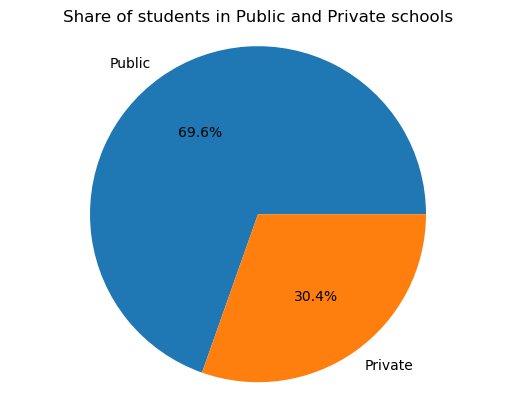

In [54]:
plt.pie(df['School_Type'].value_counts(), labels=df['School_Type'].value_counts().index, autopct='%1.1f%%')
plt.axis('equal')
plt.title("Share of students in Public and Private schools")
plt.show()

In [ ]:
# Most students are in public schools

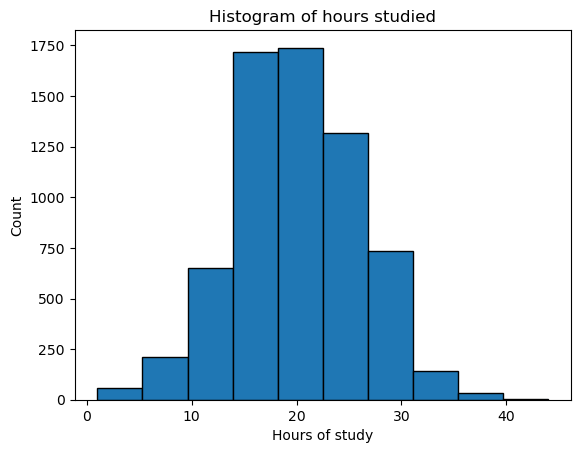

In [124]:
# Create a histogram to visualize hours studied
plt.hist(df.Hours_Studied, bins =10, edgecolor='black')
plt.title("Histogram of hours studied")
plt.xlabel('Hours of study')
plt.ylabel('Count')
plt.show;

In [ ]:
# The averae seems to be around 20. Let's check if this affects exam scores

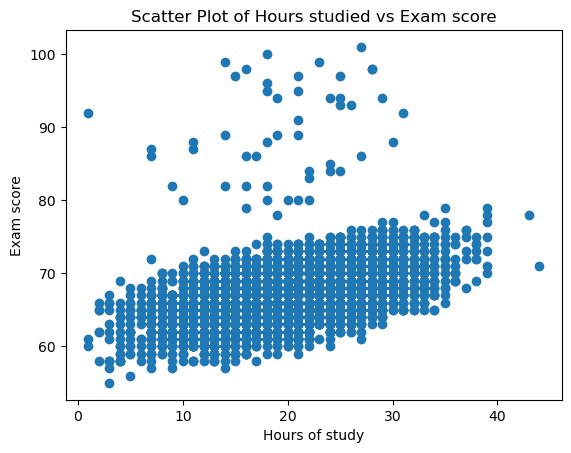

In [127]:
# Check if there is a correlation between hours studied and exam score
plt.scatter(df['Hours_Studied'], df['Exam_Score'])
plt.xlabel('Hours of study')
plt.ylabel('Exam score')
plt.title('Scatter Plot of Hours studied vs Exam score')
plt.show;

In [ ]:
# Wow. There is a positive correlation, but it doesn't appear to be very strong.
# Notice that there appears to be two groups of students; the high achievers ("geniuses") and the average achievers! 
# The high achievers do not seem to be as strongly affected by hours studies compared to the average achievers.

In [156]:
# Calculate correlation coefficient between hours studied and exam score
coeff1=df['Exam_Score'].corr(df['Hours_Studied'])
print(f"Correlation coefficient is: {coeff1}")

Correlation coefficient is: 0.4454549540752818


In [146]:
# Let us check if there is anything >80 exam scorers have in common (to confirm if it is simply "genius" or something else)
df[df['Exam_Score'] >= 79].head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
94,18,89,High,Medium,Yes,4,73,Medium,Yes,3,High,Medium,Private,Positive,2,No,College,Near,Female,100
113,35,99,High,High,Yes,7,85,Low,Yes,2,Medium,High,Private,Neutral,2,No,Postgraduate,Near,Female,79
217,19,70,Medium,Low,No,7,54,High,Yes,0,Medium,Medium,Public,Positive,2,Yes,High School,Moderate,Male,89
404,17,77,Low,High,Yes,5,53,Medium,Yes,2,High,Medium,Public,Neutral,3,No,College,Near,Male,86
529,15,83,Medium,Medium,No,7,97,Medium,Yes,2,Low,High,Private,Neutral,2,No,High School,Near,Female,97


In [ ]:
# Nothing was found to be heavily in common. They probably are geniuses after all.

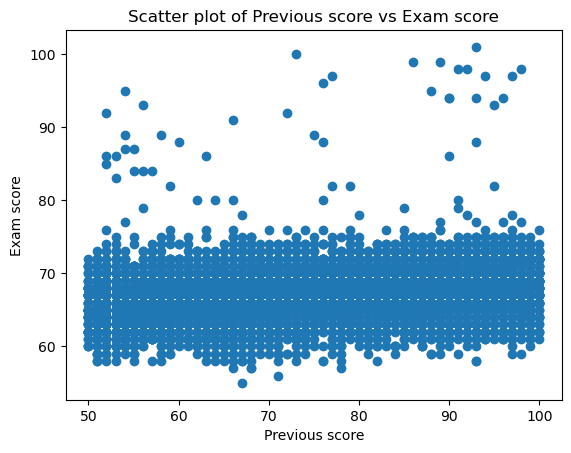

In [128]:
# Let's check if there is a relationship between previous score and final score
plt.scatter(df['Previous_Scores'], df['Exam_Score'])
plt.xlabel('Previous score')
plt.ylabel('Exam score')
plt.title('Scatter plot of Previous score vs Exam score')
plt.show;

In [ ]:
# It appears that for average achievers there is no correlation but there seems to be a weak one for the high achievers group

In [153]:
# Create a new group for high achievers and average achievers
geniuses = df[df['Exam_Score'] >=79]
average = df[df['Exam_Score'] < 79]

In [154]:
# Calculate the correlation coeffiecient between hours studied and exam score in high achieving and average group
coeff2 = geniuses['Exam_Score'].corr(geniuses['Hours_Studied'])
coeff3 = average['Exam_Score'].corr(average['Hours_Studied'])
print(f"Correlation coefficient for high achievers is {coeff2}")
print(f"Correlation coefficient for average achievers is {coeff3}")

Correlation coefficient for high achievers is 0.07297642195931797
Correlation coefficient for average achievers is 0.520599471410987


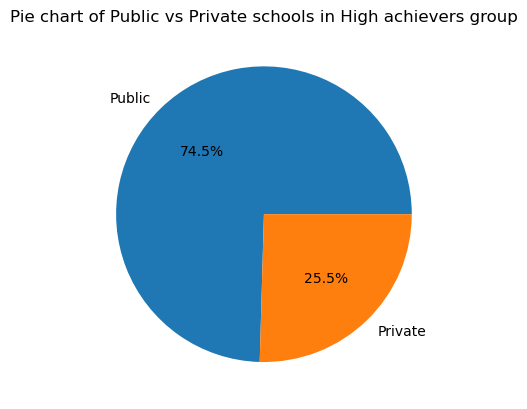

In [129]:
# Compare distribution of public and private schools between high and average achievers
plt.pie(geniuses['School_Type'].value_counts(), labels=geniuses['School_Type'].value_counts().index, autopct='%1.1f%%')
plt.title('Pie chart of Public vs Private schools in High achievers group')
plt.show()

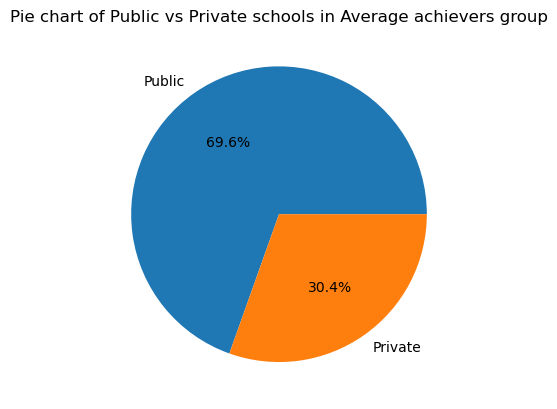

In [130]:
plt.pie(average['School_Type'].value_counts(), labels=average['School_Type'].value_counts().index, autopct='%1.1f%%')
plt.title('Pie chart of Public vs Private schools in Average achievers group')
plt.show;

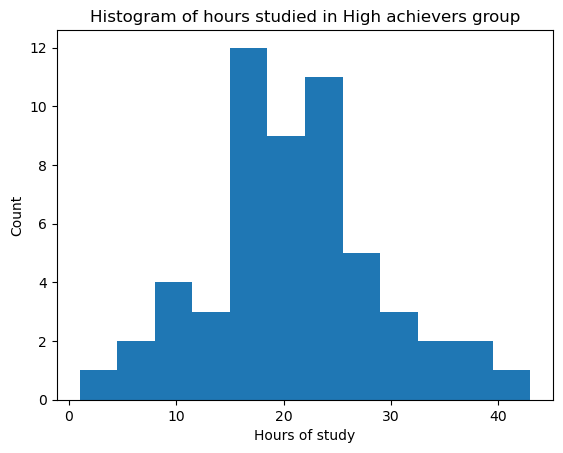

In [131]:
# Compare study hours between the two groups
plt.hist(geniuses['Hours_Studied'], bins=12)
plt.title("Histogram of hours studied in High achievers group")
plt.xlabel('Hours of study')
plt.ylabel('Count')
plt.show;

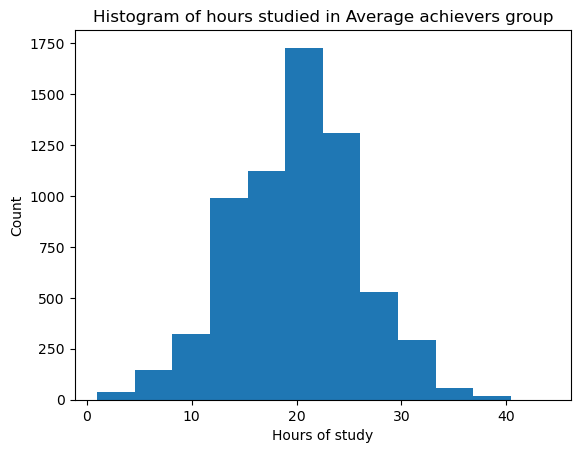

In [137]:
plt.hist(average['Hours_Studied'], bins=12)
plt.title("Histogram of hours studied in Average achievers group")
plt.xlabel('Hours of study')
plt.ylabel('Count')
plt.show;

In [133]:
# they both have roughly the same number of hours studied but there is more variation in the average group.

### SUMMARY
This dataset shows the characteristics of students who took a certain exam.
We attempted to find wehat characteristics that were associated with high performance in their exam. We found the following:
1) In general, about 70% of students went to public schools while 30% of students went to private schools.
2) Generally, the correlation coefficient between hours of study and exam score was 0.44 (moderate link).
3) There was a minority high-achieving group that behaved somewhat differently statistically from the majority average-achievers.
4) The average achievers' exam scores were moderately correlated with their study time (0.52), whereas those of the high achievers had little to no correlation (0.07).

#### BY: CHIMEREMEZE OFFURUM